## Segment syllables

In [1]:
%matplotlib inline

import pickle
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
from scipy import signal
from scipy.signal import filtfilt, spectrogram, hilbert, savgol_filter, decimate

np.set_printoptions(precision=3, suppress=True)

In [2]:
!pip install git+https://github.com/timsainb/vocalization-segmentation.git@8bc85ee9bb644cc5928535959faee5e5b184dd36
from vocalseg.continuity_filtering import continuity_segmentation, plot_labelled_elements
from VIBE.vocalseg_defaults import get_default_params

  Cloning https://github.com/timsainb/vocalization-segmentation.git (to revision 8bc85ee9bb644cc5928535959faee5e5b184dd36) to /tmp/pip-req-build-58chkkd_
  Running command git clone --filter=blob:none --quiet https://github.com/timsainb/vocalization-segmentation.git /tmp/pip-req-build-58chkkd_
  Running command git rev-parse -q --verify 'sha^8bc85ee9bb644cc5928535959faee5e5b184dd36'
  Running command git fetch -q https://github.com/timsainb/vocalization-segmentation.git 8bc85ee9bb644cc5928535959faee5e5b184dd36
  Resolved https://github.com/timsainb/vocalization-segmentation.git to commit 8bc85ee9bb644cc5928535959faee5e5b184dd36
  Preparing metadata (setup.py) ... done


In [4]:
bout_df = pd.read_pickle('bird_A_songs.pkl')

#### Generate and review clustered acoustics

In [5]:
get_default_params()

{'n_fft': 512,
 'hop_length_ms': 1,
 'win_length_ms': 5,
 'ref_level_db': 10,
 'pre': 0.97,
 'min_level_db': -120,
 'silence_threshold': 0.07,
 'spectral_range': [400, 6000],
 'mask_thresh_std': 1.0,
 'figsize': (30, 3),
 'min_silence_for_spec': 0.01,
 'neighborhood_thresh': 0.25,
 'neighborhood_time_ms': 5,
 'neighborhood_freq_hz': 2000,
 'temporal_neighbor_merge_distance_ms': 5,
 'overlapping_element_merge_thresh': 0.25,
 'min_element_size_ms_hz': [10, 1000]}

In [12]:
seg_params = get_default_params()
seg_params['min_element_size_ms_hz'] = [20, 500]
seg_params['silence_threshold']: 0.01

def segment_bout(x: np.array, fs: int, verbose=True) -> dict:
    results = continuity_segmentation(
        x, # audio waveform
        fs, # sampling rate
        **seg_params, # segmentation parameters
        verbose=verbose # display output
    )
    return results

### Run the following three blocks for a few example bouts
Tune segmentation parameters

longest silence 0.481
longest vocalization 0.14500000000000046


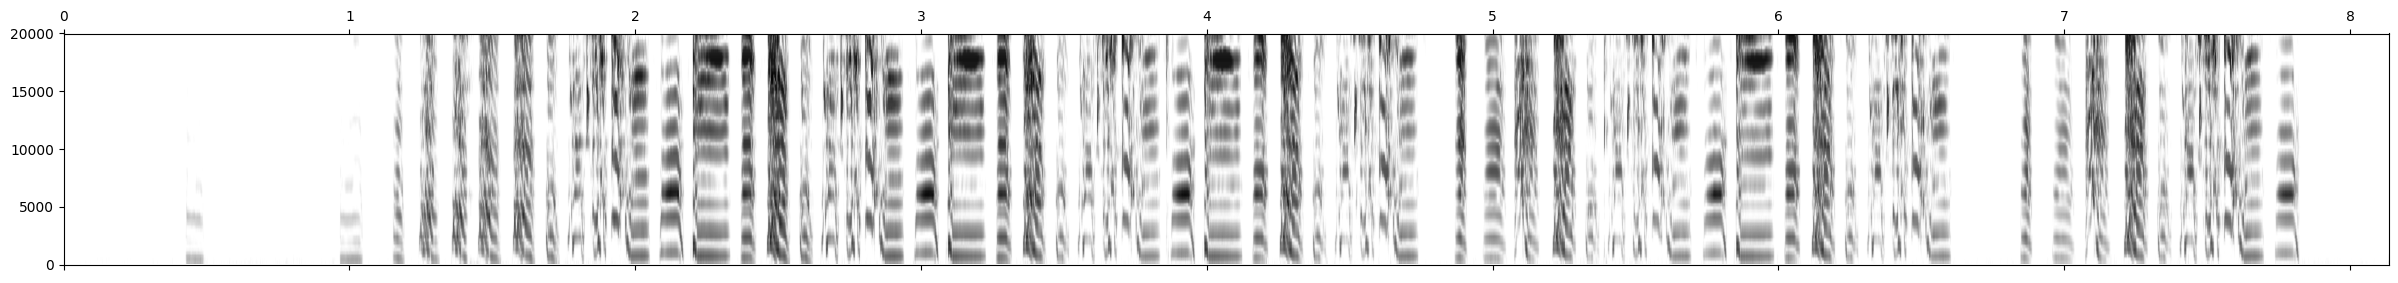

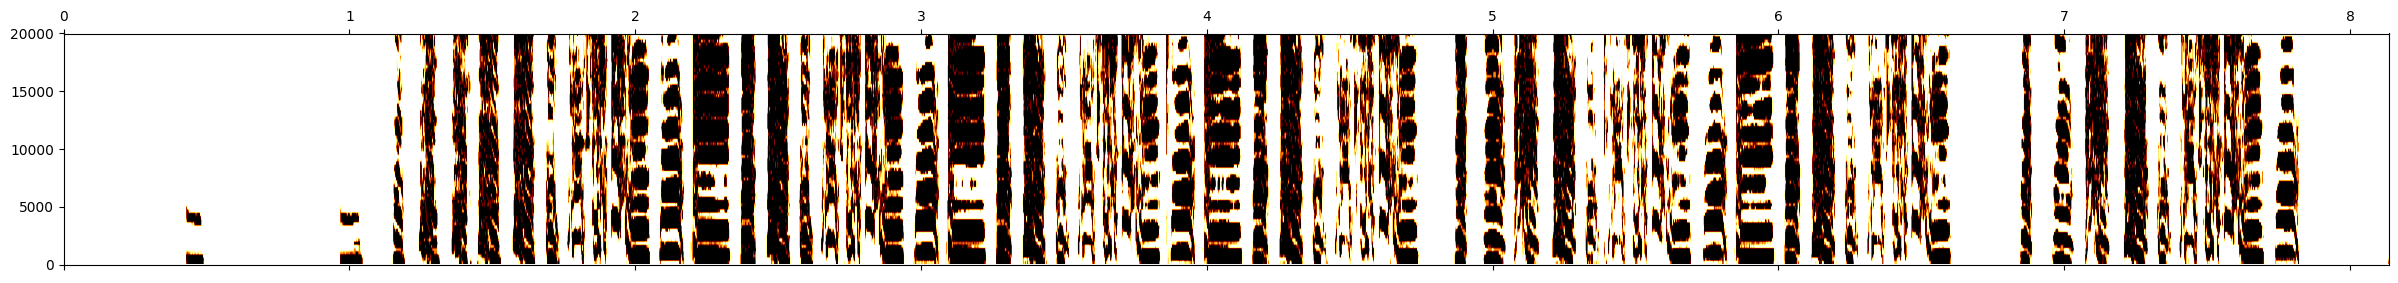

(25, 5)


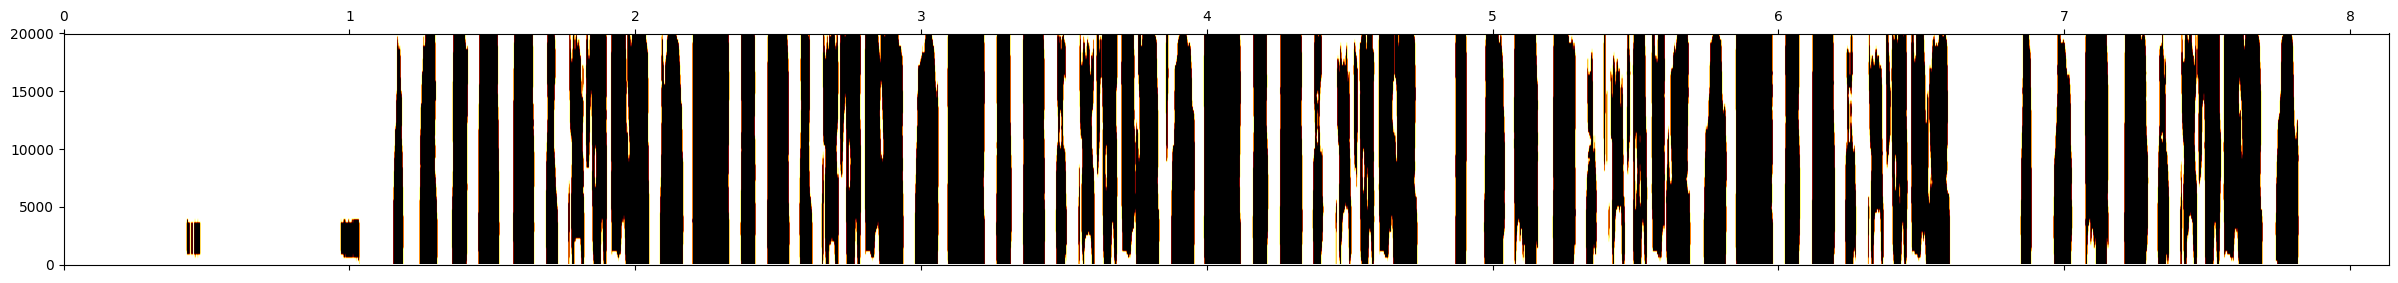

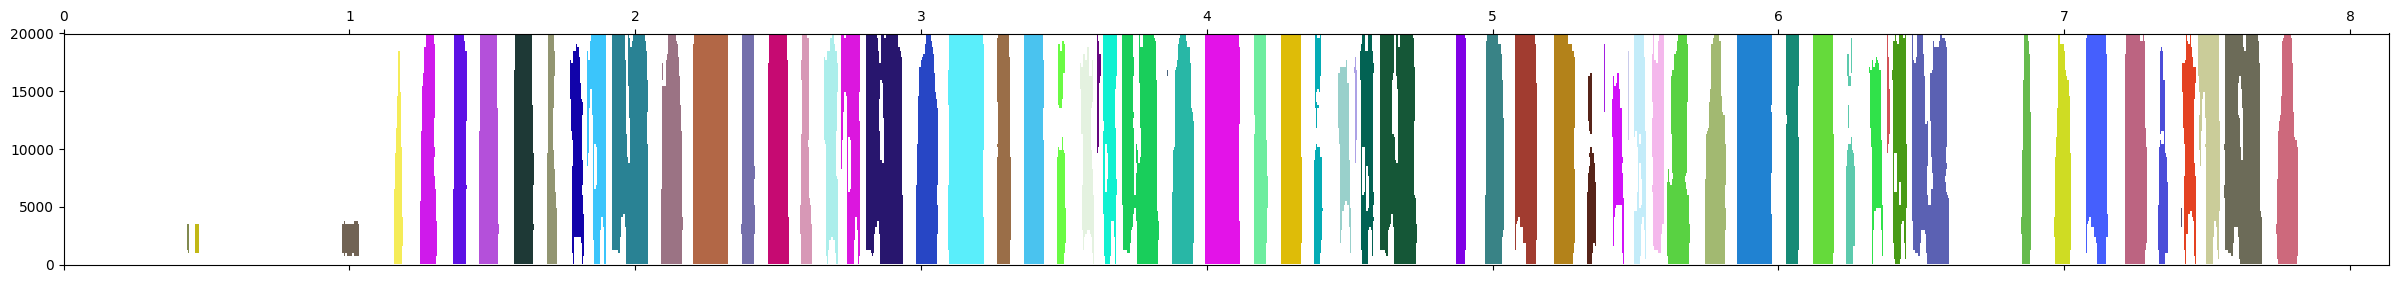

element coverage:   0%|          | 0/78 [00:00<?, ?it/s]

element length:   0%|          | 0/78 [00:00<?, ?it/s]

unique elements: 78


merging temporal neighbors:   0%|          | 0/78 [00:00<?, ?it/s]

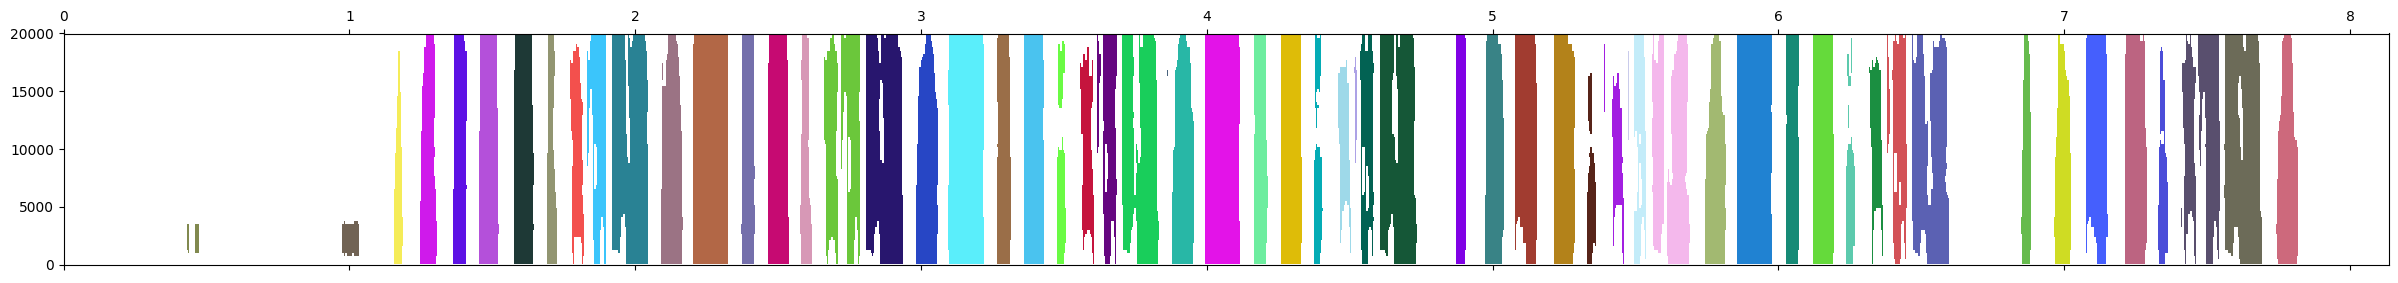

unique elements: 61
128


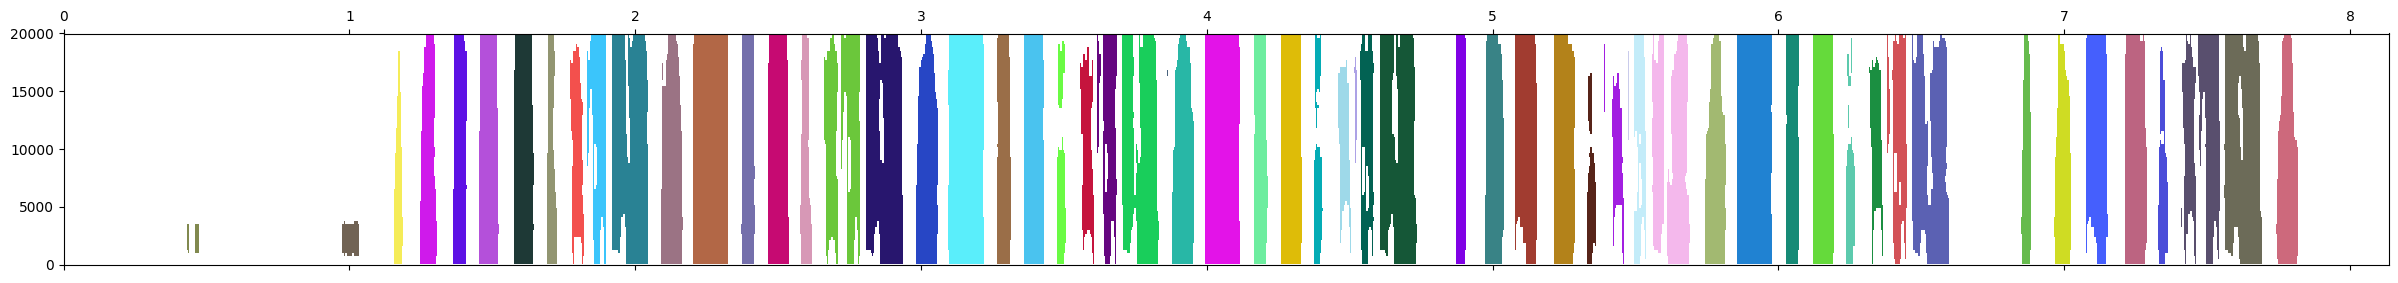

unique elements: 61


In [13]:
bout_idx = 0
x = bout_df.iloc[bout_idx]['waveform'].flatten()
x = x.astype(float)/np.max(np.abs(x))
results = segment_bout(x, bout_df.iloc[bout_idx]['sample_rate'])

  0%|          | 0/61 [00:00<?, ?it/s]

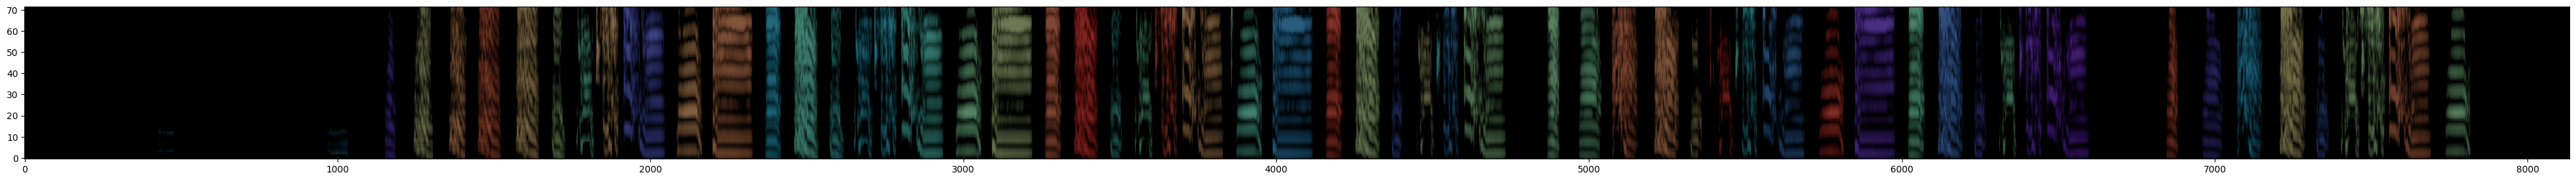

In [14]:
labelled_spec = plot_labelled_elements(results['elements'], results['spec'], background='black', figsize=(50,3)); 

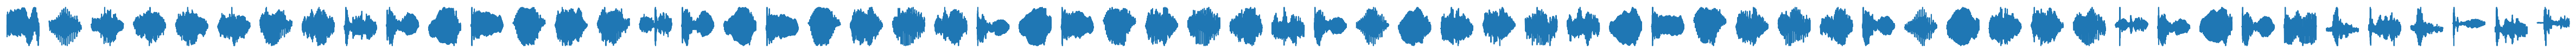

In [15]:
fig, axs = plt.subplots(ncols=len(results['onsets']), figsize= (len(results['onsets']),1))
for axi, (onset, offset) in enumerate(zip(results['onsets'], results['offsets'])):
    axs[axi].plot(x[int(onset*bout_df.iloc[0]['sample_rate']):int(offset*bout_df.iloc[0]['sample_rate'])])
    axs[axi].axis('off')

## When satisfied with parameters, run for full session

In [16]:
# create bouts_segmented dataframe
bouts_segmented = bout_df.copy()
bouts_segmented['on_ms'] = None
bouts_segmented['off_ms'] = None
bouts_segmented['on_sample'] = None
bouts_segmented['off_sample'] = None

empty_waveforms = []
for bout_idx in bouts_segmented.index.to_list():
    
    # segment bouts
    x = bout_df.loc[bout_idx]['waveform'].flatten()
    if x.size==0:
        print(f"- bout_idx {bout_idx}: empty waveform, skipping...")
        empty_waveforms.append(bout_idx)
        continue
    x = x.astype(float)/np.max(np.abs(x))
    results = segment_bout(x, bout_df.iloc[bout_idx]['sample_rate'], verbose=False)
    
    # update bouts_segmented
    bouts_segmented.at[bout_idx, 'on_ms'] = (np.array(results['onsets']) * 1000).astype(int)
    bouts_segmented.at[bout_idx, 'off_ms'] = (np.array(results['offsets']) * 1000).astype(int)
    bouts_segmented.at[bout_idx, 'on_sample'] = (np.array(results['onsets']) * bout_df.at[bout_idx, 'sample_rate']).astype(int)
    bouts_segmented.at[bout_idx, 'off_sample'] = (np.array(results['offsets']) * bout_df.at[bout_idx, 'sample_rate']).astype(int)
    
bouts_segmented = bouts_segmented.drop(index=empty_waveforms)

(25, 5)


element coverage:   0%|          | 0/78 [00:00<?, ?it/s]

element length:   0%|          | 0/78 [00:00<?, ?it/s]

unique elements: 78


merging temporal neighbors:   0%|          | 0/78 [00:00<?, ?it/s]

128


#### Make separated syllables

In [17]:
# create a dataframe for segmented syllables
dfs = []
for index, row in bouts_segmented.iterrows():
    sample_rate = row['sample_rate']
    bout_index = index
    bout_waveform = row['waveform']
    on_samples = row['on_sample']
    off_samples = row['off_sample']
    on_mss = row['on_ms']
    off_mss = row['off_ms']
    data = []
    for syllable_index, (on_sample, 
                         off_sample, 
                         on_ms, 
                         off_ms) in enumerate(zip(on_samples, 
                                                  off_samples, 
                                                  on_mss, 
                                                  off_mss)
                                              ):
        
        data.append({
            'sample_rate': sample_rate,
            'bout_index': bout_index,
            'bout_waveform': bout_waveform,
            'syllable_index': syllable_index,
            'on_sample': on_sample,
            'off_sample': off_sample,
            'on_ms': on_ms,
            'off_ms': off_ms,
            'syllable_waveform': bout_waveform[on_sample:off_sample]})
    
    df = pd.DataFrame(data)
    dfs.append(df)

syl_df = pd.concat(dfs, ignore_index=True)

In [18]:
# remove empty syllables (product of errors in segmentation)
empty_rows = []
for i, arr in enumerate(syl_df.syllable_waveform.values):
    if len(arr) == 0: empty_rows.append(i)
if empty_rows:
    print('Bouts with empty syllables:', syl_df.iloc[empty_rows]['bout_index'].unique())

syl_df = syl_df[syl_df['syllable_waveform'].apply(lambda x: len(x) != 0)]

In [19]:
# remove segs under 20ms
syl_df = syl_df.sort_values(by=['bout_index', 'on_ms'])
syl_df = syl_df[(syl_df['off_ms'] - syl_df['on_ms']) >= 20]
syl_df['syllable_index'] = syl_df.groupby('bout_index').cumcount()
syl_df = syl_df.reset_index(drop=True)

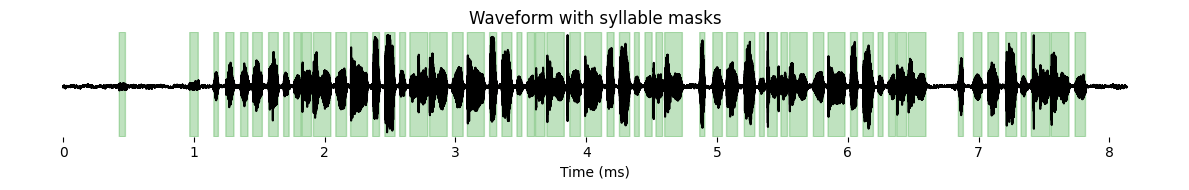

In [78]:
# plot example song with syllable segmentations
bout_idx = 0

fig, ax = plt.subplots(figsize=(12, 2))
y = bout_df.iloc[bout_idx]['waveform']
y = y/max(np.min(y), np.max(y), key=abs)
fs_audio = bout_df.iloc[bout_idx]['sample_rate']
time_wav = np.arange(len(y)) / fs_audio

ax.plot(time_wav, y / np.abs(y).max(), 'k')
syl_rows = syl_df[syl_df['bout_index'] == bout_idx]

win_length=int(0.016*fs_audio)
hop_length=int(0.004*fs_audio)
n_fft=2 ** math.ceil(math.log2(win_length))
def get_stft_frame_count(y, fs, win_length, hop_length, n_fft):
    _, t, _ = signal.stft(y, fs=fs, window='hann', nperseg=win_length,
                          noverlap=win_length-hop_length, nfft=n_fft,
                          return_onesided=True, boundary='zeros', padded=True)
    return len(t)

T = get_stft_frame_count(y, fs_audio, win_length, hop_length, n_fft)
m = np.zeros(len(y), dtype=bool)
for _, syl in syl_rows.iterrows():
    start_n = max(int(syl['on_sample']), 0)
    end_n   = min(int(syl['off_sample']), len(y))
    m[start_n:end_n] = True
ax.fill_between(time_wav, -1, 1, where=m, alpha=0.3, color='C2')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.set_title('Waveform with syllable masks')
ax.set_xlabel('Time (ms)')
ax.set_ylim([-1, 1])
ax.set_yticks([])
plt.tight_layout()
plt.show()

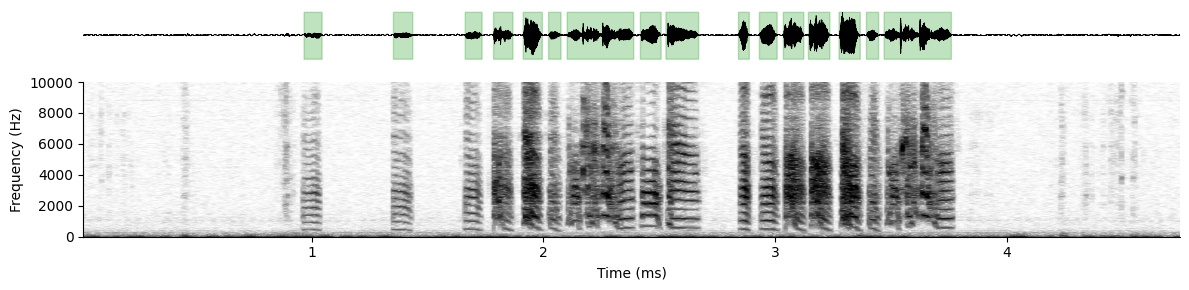

In [74]:
fig, ax = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [1,3]}, figsize=(12, 3))
bout_idx = 12
x = bout_df.iloc[bout_idx].waveform
x = x/max(np.min(x), np.max(x), key=abs)
fs = bout_df.iloc[bout_idx].sample_rate
t_wave = np.arange(len(x)) / fs
freq, t_spec, Sxx = spectrogram(x, fs=fs, nperseg=1024, noverlap=768)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

# sound waveform
ax[0].plot(t_wave, x, 'black', lw=0.5)
T = get_stft_frame_count(x, fs_audio, win_length, hop_length, n_fft)
m = np.zeros(len(x), dtype=bool)
syl_rows = syl_df[syl_df['bout_index'] == bout_idx]
for _, syl in syl_rows.iterrows():
    start_n = max(int(syl['on_sample']), 0)
    end_n   = min(int(syl['off_sample']), len(x))
    m[start_n:end_n] = True
ax[0].fill_between(t_wave, -1, 1, where=m, alpha=0.3, color='C2')
ax[0].set_xlim([t_wave[0], t_wave[-1]])
ax[0].set_axis_off()
ax[0].set_ylabel('Amplitude')

# spectrogram
fmask = freq <= 10000
ax[1].pcolormesh(t_spec, freq[fmask], Sxx_db[fmask], cmap='Greys', shading='gouraud',
                      vmin=np.percentile(Sxx_db, 20), vmax=np.percentile(Sxx_db, 99.9))
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_xlabel('Time (ms)')
ax[1].set_xlim([t_spec[0], t_spec[-1]])
ax[1].set_ylim([0, 10000])
ax[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [79]:
syl_df.to_pickle('bird_A_syls.pkl')